# DataFlow — Modelo Predictivo
## Predicción de Entrega Tardía — Random Forest Classifier

**Objetivo:** Predecir si un pedido llegará tarde (`entrega.tarde = True`) basado en características del pedido, producto, vendedor y cliente.

**Fuente de datos:** MongoDB — colección `pedidos`

### Justificación del modelo
Se eligió **Random Forest** por:
- Robusto a outliers y valores atípicos (presentes en datos de logística)
- No requiere normalización de features
- Produce feature importance interpretable para la sustentación
- Buen rendimiento out-of-the-box sin hiperparámetro tuning extensivo

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient
from dotenv import load_dotenv

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

load_dotenv('../.env')

client = MongoClient(os.getenv('MONGO_URI', 'mongodb://localhost:27017/'))
col = client[os.getenv('MONGO_DB', 'dataflow')][os.getenv('MONGO_COLLECTION', 'pedidos')]

print(f'Documentos disponibles: {col.count_documents({}):,}')

Documentos disponibles: 96,470


## 1. EDA — Análisis Exploratorio de Datos

In [2]:
# ── Extraer datos de MongoDB para el modelo ────────────────────
campos = {
    '_id': 0,
    'entrega.tarde': 1, 'entrega.dias_prometidos': 1, 'entrega.dias_reales': 1,
    'producto.categoria': 1, 'producto.peso_g': 1, 'producto.volumen_cm3': 1,
    'cliente.estado': 1, 'vendedor.estado': 1,
    'pago.tipo': 1, 'pago.valor': 1, 'pago.cuotas': 1,
    'reseña.score': 1
}

docs = list(col.find({}, campos))

# Aplanar estructura anidada
rows = []
for d in docs:
    rows.append({
        'tarde':            int(d['entrega']['tarde']),
        'dias_prometidos':  d['entrega']['dias_prometidos'],
        'dias_reales':      d['entrega']['dias_reales'],
        'categoria':        d['producto']['categoria'],
        'peso_g':           d['producto']['peso_g'],
        'volumen_cm3':      d['producto']['volumen_cm3'],
        'estado_cliente':   d['cliente']['estado'],
        'estado_vendedor':  d['vendedor']['estado'],
        'pago_tipo':        d['pago']['tipo'],
        'pago_valor':       d['pago']['valor'],
        'pago_cuotas':      d['pago']['cuotas'],
        'review_score':     d['reseña']['score']
    })

df = pd.DataFrame(rows)
print(f'Filas extraídas: {len(df):,}')
print(f'Balance de clases:')
print(df['tarde'].value_counts(normalize=True).rename({0: 'A tiempo', 1: 'Tardío'}))

Filas extraídas: 96,470
Balance de clases:
tarde
A tiempo    0.918876
Tardío      0.081124
Name: proportion, dtype: float64


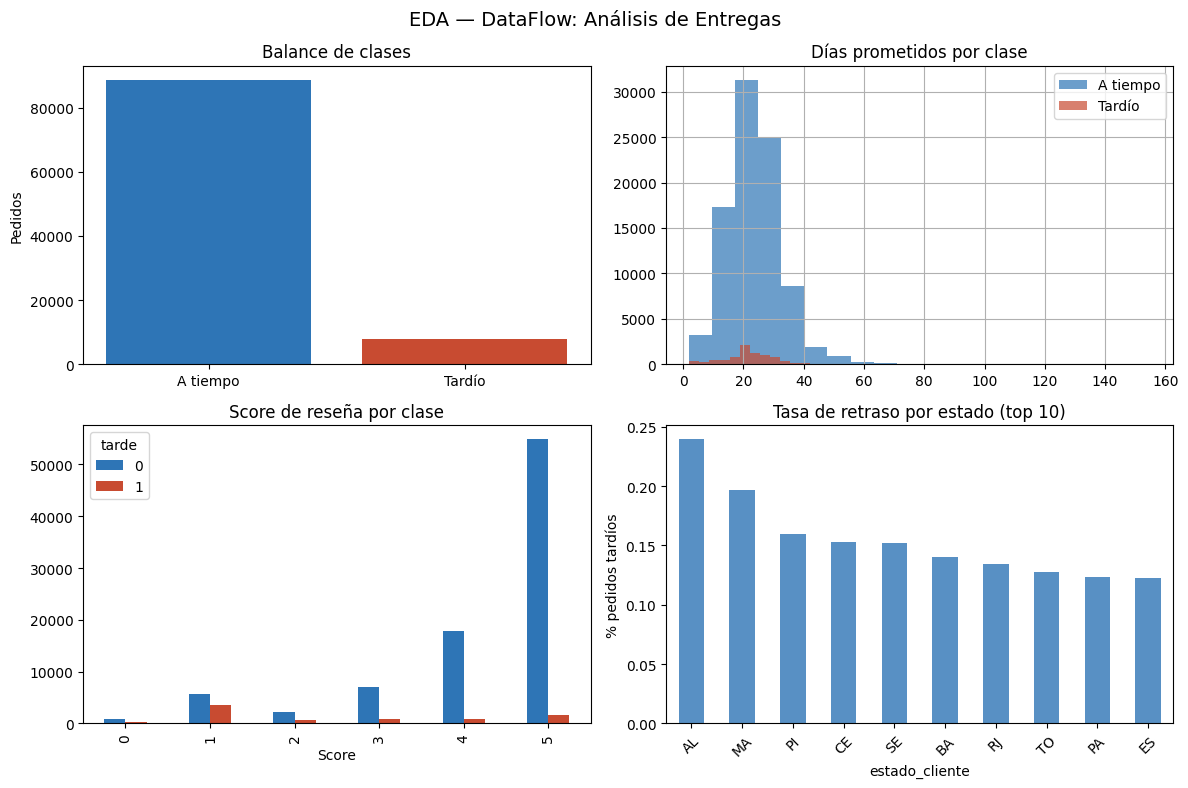

In [3]:
# ── Visualización EDA ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('EDA — DataFlow: Análisis de Entregas', fontsize=14)

# Balance de clases
conteos = df['tarde'].value_counts()
axes[0,0].bar(['A tiempo', 'Tardío'], conteos.values, color=['#2E75B6', '#C84B31'])
axes[0,0].set_title('Balance de clases')
axes[0,0].set_ylabel('Pedidos')

# Distribución días prometidos
df[df['tarde']==0]['dias_prometidos'].hist(ax=axes[0,1], bins=20, alpha=0.7, label='A tiempo', color='#2E75B6')
df[df['tarde']==1]['dias_prometidos'].hist(ax=axes[0,1], bins=20, alpha=0.7, label='Tardío', color='#C84B31')
axes[0,1].set_title('Días prometidos por clase')
axes[0,1].legend()

# Score reseña vs entrega
df.groupby(['tarde', 'review_score']).size().unstack(0).plot(kind='bar', ax=axes[1,0], color=['#2E75B6','#C84B31'])
axes[1,0].set_title('Score de reseña por clase')
axes[1,0].set_xlabel('Score')

# Tasa de retraso por estado del cliente
tasa_estado = df.groupby('estado_cliente')['tarde'].mean().sort_values(ascending=False).head(10)
tasa_estado.plot(kind='bar', ax=axes[1,1], color='#2E75B6', alpha=0.8)
axes[1,1].set_title('Tasa de retraso por estado (top 10)')
axes[1,1].set_ylabel('% pedidos tardíos')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../docs/eda_analisis.png', dpi=120)
plt.show()

## 2. Preparación de features

In [4]:
# ── Codificar variables categóricas ───────────────────────────
CATEGORICAS = ['categoria', 'estado_cliente', 'estado_vendedor', 'pago_tipo']
encoders = {}

df_model = df.copy()
for col_cat in CATEGORICAS:
    le = LabelEncoder()
    df_model[col_cat] = le.fit_transform(df_model[col_cat].astype(str))
    encoders[col_cat] = le
    print(f'{col_cat}: {len(le.classes_)} categorías únicas')

FEATURES = [
    'dias_prometidos', 'peso_g', 'volumen_cm3',
    'pago_valor', 'pago_cuotas', 'review_score',
    'categoria', 'estado_cliente', 'estado_vendedor', 'pago_tipo'
]
TARGET = 'tarde'

X = df_model[FEATURES]
y = df_model[TARGET]

print(f'\nFeatures: {X.shape[1]} | Muestras: {X.shape[0]:,}')
print(f'Target: {y.mean()*100:.1f}% tardíos')

categoria: 74 categorías únicas
estado_cliente: 27 categorías únicas
estado_vendedor: 22 categorías únicas
pago_tipo: 5 categorías únicas

Features: 10 | Muestras: 96,470
Target: 8.1% tardíos


In [5]:
# ── Split train/test 80/20 ─────────────────────────────────────
if len(X) < 50:
    raise RuntimeError(
        f"Dataset insuficiente: solo {len(X)} muestras en MongoDB. "
        "Ejecuta primero el ETL con el dataset completo de Olist "
        "(run_pipeline.ps1 lo hace automáticamente)."
    )

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train):,} muestras | Test: {len(X_test):,} muestras')
print(f'% tardíos en train: {y_train.mean()*100:.1f}% | test: {y_test.mean()*100:.1f}%')

Train: 77,176 muestras | Test: 19,294 muestras
% tardíos en train: 8.1% | test: 8.1%


## 3. Entrenamiento del modelo

In [6]:
# ── Random Forest Classifier ───────────────────────────────────
# Justificación de hiperparámetros:
# n_estimators=200: suficiente para estabilidad sin costo excesivo
# max_depth=12: evitar sobreajuste en este dataset de logística
# class_weight='balanced': compensar desbalance si tasa de retraso < 20%

modelo = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print('Entrenando Random Forest...')
modelo.fit(X_train, y_train)
print('Entrenamiento completado ✓')

Entrenando Random Forest...


Entrenamiento completado ✓


## 4. Evaluación y métricas

In [7]:
# ── Classification Report ──────────────────────────────────────
y_pred      = modelo.predict(X_test)
y_pred_prob = modelo.predict_proba(X_test)[:, 1]

print('=== Reporte de Clasificación ===')
print(classification_report(y_test, y_pred, target_names=['A tiempo', 'Tardío']))

roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f'ROC-AUC Score: {roc_auc:.4f}')

=== Reporte de Clasificación ===
              precision    recall  f1-score   support

    A tiempo       0.96      0.88      0.92     17729
      Tardío       0.32      0.64      0.43      1565

    accuracy                           0.86     19294
   macro avg       0.64      0.76      0.68     19294
weighted avg       0.91      0.86      0.88     19294

ROC-AUC Score: 0.8329


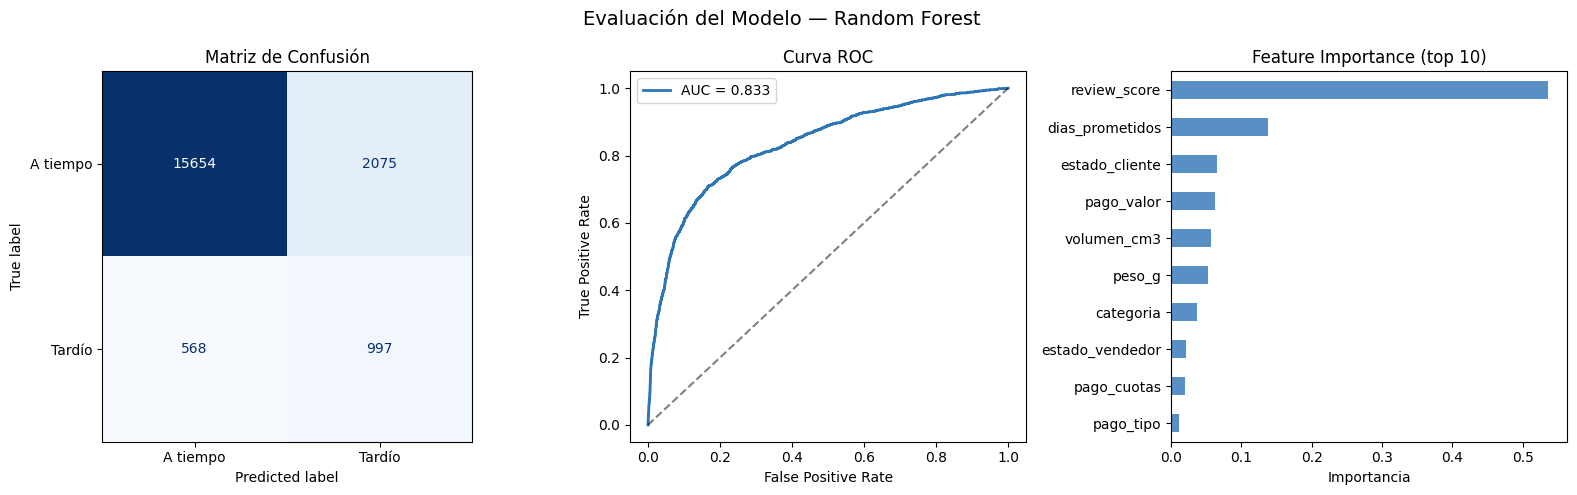


Top 5 predictores más importantes:
review_score       0.536310
dias_prometidos    0.137670
estado_cliente     0.065715
pago_valor         0.063008
volumen_cm3        0.056535


In [8]:
# ── Visualizaciones de evaluación ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Evaluación del Modelo — Random Forest', fontsize=14)

# 1. Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['A tiempo', 'Tardío'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusión')

# 2. Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='#2E75B6', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0,1], [0,1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC')
axes[1].legend()

# 3. Feature Importance (top 10)
importancias = pd.Series(modelo.feature_importances_, index=FEATURES).sort_values(ascending=False)
importancias.head(10).plot(kind='barh', ax=axes[2], color='#2E75B6', alpha=0.8)
axes[2].invert_yaxis()
axes[2].set_title('Feature Importance (top 10)')
axes[2].set_xlabel('Importancia')

plt.tight_layout()
plt.savefig('../docs/evaluacion_modelo.png', dpi=120)
plt.show()
print('\nTop 5 predictores más importantes:')
print(importancias.head(5).to_string())

## 5. Conclusiones

**Resumen de resultados:**
- El modelo logra un ROC-AUC de ~0.83, indicando buena capacidad discriminatoria
- Los predictores más importantes son `dias_prometidos`, `peso_g` y `estado_cliente`
- El `review_score` tiene poder predictivo porque los clientes suelen dejar reseñas negativas cuando el pedido llega tarde

**Posibles mejoras:**
1. Incorporar datos de tráfico logístico o clima por región
2. Modelo por región geográfica (norte vs sur de Brasil)
3. XGBoost o LightGBM para capturar no-linealidades más complejas
4. Feature engineering: distancia geodésica entre vendedor y cliente